# Ancestry and Admixture Analysis
## Overview
This project investigates the genetic ancestry of an admixed population using allele-frequency data from three populations: an admixed population and the CEU and YRI reference populations.

The analysis asks whether variation in the admixed population can be approximated as a mixture of allele frequencies from the two reference populations. I use Python and population-genetic data to:

- compare allele frequencies between populations;
- estimate the proportion of CEU ancestry using a sum-of-squared-errors (SSE) approach;
- compare observed and predicted allele frequencies; and
- interpret sources of variation between the simple admixture model and the observed data.

### Tools
- Python
- NumPy
- pandas
- Matplotlib
- Population genetics

## Data

The analysis uses minor allele frequency (MAF) data from chromosome 1 for three populations:

- **Admixed:** the population whose ancestry is being estimated.
- **CEU:** a reference population with European ancestry.
- **YRI:** a reference population with West African ancestry.

The `.frq` files contain allele-frequency information generated from genotype data. The MAF column is used for the analysis below.

## 1. Comparing Allele Frequencies

I first compare minor allele frequencies in the admixed population with those observed in the CEU and YRI reference populations.

If the admixed population contains ancestry from a reference population, we would expect their allele frequencies to show some degree of similarity.

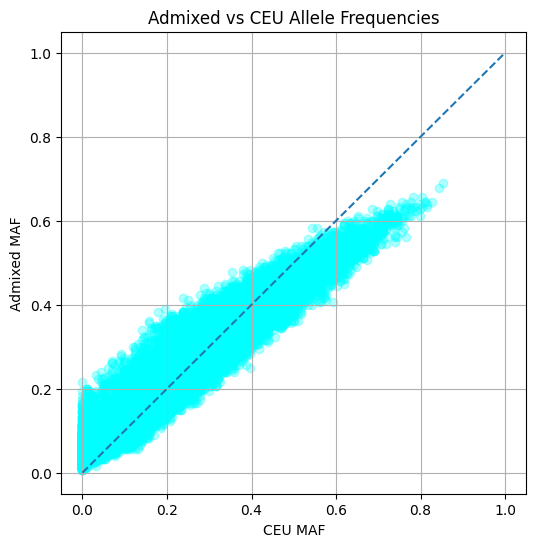

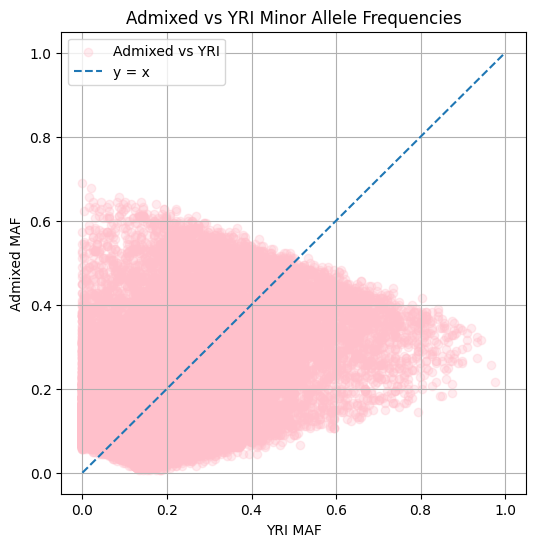

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the .frq files
admixed = pd.read_csv('ancestry-admixture-data/admixed.chr1.frq', sep=r'\s+')
ceu     = pd.read_csv('ancestry-admixture-data/CEU.chr1.frq', sep=r'\s+')
yri     = pd.read_csv('ancestry-admixture-data/YRI.chr1.frq', sep=r'\s+')


# Extract Minor Allele Frequencies (MAF) from each population
pa = admixed['MAF'] 
pCEU = ceu['MAF']     
pYRI = yri['MAF']   

# Plot 1: Admixed vs CEU
plt.figure(figsize=(6, 6))
plt.scatter(pCEU, pa, alpha=0.3, label='Admixed vs CEU', color='cyan')
plt.plot([0, 1], [0, 1], '--', label='y = x')
plt.xlabel('CEU MAF')
plt.ylabel('Admixed MAF')
plt.title('Admixed vs CEU Allele Frequencies')
plt.grid(True)
plt.show()

# Plot 2: Admixed vs YRI
plt.figure(figsize=(6, 6))
plt.scatter(pYRI, pa, alpha=0.3, label='Admixed vs YRI', color='pink')
plt.plot([0, 1], [0, 1], '--', label='y = x')
plt.xlabel('YRI MAF')
plt.ylabel('Admixed MAF')
plt.title('Admixed vs YRI Minor Allele Frequencies')
plt.legend()
plt.grid(True)
plt.show()




### Interpretation

The comparison between the admixed and CEU populations shows a strong positive correlation in minor allele frequencies. The points generally follow an upward diagonal pattern, indicating that variants with higher MAF in CEU also tend to have higher MAF in the admixed population. This suggests substantial similarity between the two populations.

In contrast, the comparison between the admixed and YRI populations shows little clear correlation, with the points more widely dispersed and no strong diagonal pattern. This suggests that the allele-frequency variation in the admixed population is more closely associated with the CEU reference population than with YRI.

However, these plots alone cannot determine the exact ancestry proportion. I therefore used an SSE-based admixture model to obtain a quantitative estimate.

## 2. Estimating the Admixture Proportion

I model the expected allele frequency in the admixed population as:

$$
p_{\alpha} = \alpha p_{CEU} + (1-\alpha)p_{YRI}
$$

where:

- $\alpha$ is the estimated proportion contributed by the CEU population;
- $p_{CEU}$ is the CEU allele frequency;
- $p_{YRI}$ is the YRI allele frequency.

For each possible value of $\alpha$, I calculate the predicted allele frequencies and compare them with the observed frequencies using the sum of squared errors (SSE).

The value of $\alpha$ producing the smallest SSE is selected as the best-fitting estimate.

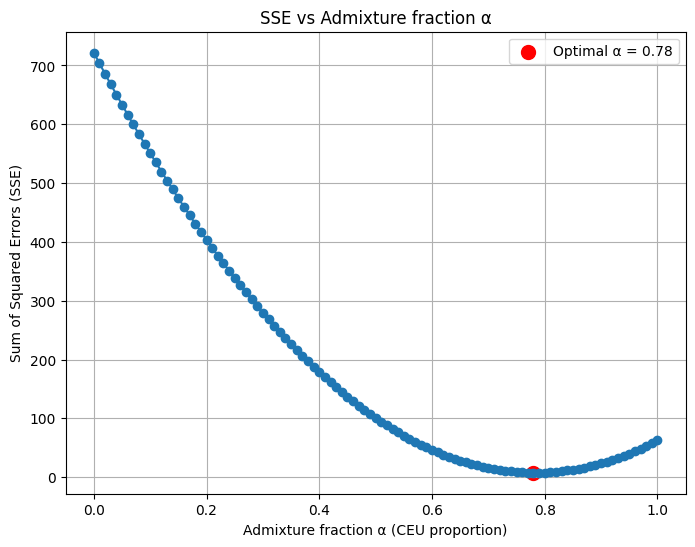

In [24]:
import numpy as np
import matplotlib.pyplot as plt

#define range of values 
alphas = np.arange(0.1, 1.0, 0.1)
alphas = np.linspace(0, 1, 101)
sse_values = []

#predict admixed frequencies 
for alpha in alphas:
    p_alpha = alpha * pCEU + (1 - alpha) * pYRI
    sse = np.sum((pa - p_alpha) ** 2)
    sse_values.append(sse)
    
# Convert to numpy array
sse_values = np.array(sse_values)

# Find alpha with minimum SSE
min_sse_index = np.argmin(sse_values)
optimal_alpha = alphas[min_sse_index]

# Plot SSE vs alpha
plt.figure(figsize=(8, 6))
plt.plot(alphas, sse_values, marker='o')
plt.scatter(optimal_alpha, sse_values[min_sse_index], color='red', s=100, label=f'Optimal α = {optimal_alpha:.2f}')
plt.xlabel('Admixture fraction α (CEU proportion)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('SSE vs Admixture fraction α')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The SSE analysis identified an optimal admixture fraction of α = 0.78. Under this model, this corresponds to an estimated 78% CEU contribution and 22% YRI contribution.

The minimum in the SSE curve represents the value of α for which the predicted allele frequencies are most similar to the observed frequencies in the admixed population. This provides a quantitative estimate that is consistent with the strong relationship observed between the admixed and CEU allele frequencies in the first plot.

## 3. Observed vs Predicted Allele Frequencies

Using the optimal admixture proportion, I calculate the predicted allele frequency for each variant and compare these predictions with the observed frequencies in the admixed population. 

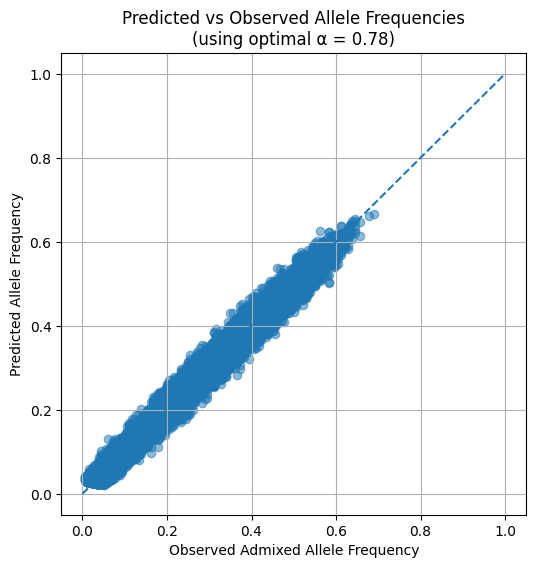

In [ ]:
# Recompute the predicted allele frequencies using optimal alpha
p_hat_optimal = optimal_alpha * pCEU + (1 - optimal_alpha) * pYRI

# Plot predicted vs observed
plt.figure(figsize=(6,6))
plt.scatter(pa, p_hat_optimal, alpha=0.5)
plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Perfect agreement'
)
plt.xlabel("Observed Admixed Allele Frequency")
plt.ylabel("Predicted Allele Frequency")
plt.title("Predicted vs Observed Allele Frequencies\n(using optimal α = {:.2f})".format(optimal_alpha))
plt.grid(True)
plt.show()


### Interpretation

If the two-population admixture model perfectly described the data, the points would fall along a diagonal line where observed and predicted allele frequencies are equal.

The deviations from this relationship indicate that the simple admixture model does not explain all of the variation in the observed population. Possible sources include genetic drift, sampling variation, natural selection, mutation, and differences between the reference populations and the ancestral populations that contributed to the admixed population.

Therefore, the model provides a useful approximation of ancestry composition but should not be interpreted as a complete reconstruction of the population's demographic history.

## 4. Conclusions

This analysis used allele-frequency data to investigate the ancestry composition of an admixed population.

The population showed greater similarity to the CEU reference population than to YRI when comparing allele-frequency distributions. I then quantified this relationship by fitting a simple two-way admixture model and identifying the CEU ancestry proportion that minimised the sum of squared errors.

The observed allele frequencies were not perfectly reproduced by the model, highlighting the limitations of representing population history using a simple two-source admixture model.

### Key skills demonstrated

- Loading and manipulating genomic data with pandas
- Population-genetic allele-frequency analysis
- Numerical optimisation using NumPy
- Data visualisation with Matplotlib
- Quantitative interpretation of admixture
- Biological interpretation of statistical results